# UNet

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torchmetrics

import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.image import StructuralSimilarityIndexMeasure

# ============================================================
# SETUP PATH
# ============================================================

WORK_DIR = Path("/content/drive/MyDrive/Computational Imaging/Code")
RETINA_DATASET_PATH = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images")

# Cartella dove salveremo il dataset preprocessato in .pt
PROCESSED_DATASET_DIR = Path("/content/drive/MyDrive/Computational Imaging/Dataset/retina_processed")

# Find IPPy folder
for base in (WORK_DIR, *WORK_DIR.parents):
    if (base / "IPPy").exists():
        sys.path.append(str(base))
        break
else:
    raise FileNotFoundError("Could not find IPPy folder.")

from IPPy import operators, utilities

device = utilities.get_device()
torch.manual_seed(0)

print("Device:", device)
print("Working directory:", WORK_DIR)
print("Retina dataset path:", RETINA_DATASET_PATH)
print("Processed dataset path:", PROCESSED_DATASET_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.1 MB/s eta 0:00:0000:01
Device: cuda
Working directory: /content/drive/MyDrive/Computational Imaging/Code
Retina dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images
Processed dataset path: /content/drive/MyDrive/Computational Imaging/Dataset/retina_processed


## Dataset

In [3]:
class RetinaPTDataset(Dataset):
    def __init__(self, pt_path):
        super().__init__()

        payload = torch.load(pt_path, map_location="cpu")

        self.clean = payload["clean"]
        self.degraded = payload["degraded"]
        self.source_paths = payload["source_paths"]
        self.metadata = payload["metadata"]

    def __len__(self):
        return self.clean.shape[0]

    def __getitem__(self, idx):
        y = self.degraded[idx]   # input degradato
        x = self.clean[idx]      # target pulito
        return y, x

def noise_file_name(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}.pt"

## Dataloader

In [4]:
# ============================================================
# DATALOADERS FOR DIFFERENT NOISE LEVELS
# ============================================================

NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]
batch_size = 8


def create_dataloaders_for_noise(noise_level):
    train_pt = PROCESSED_DATASET_DIR / "train" / noise_file_name(noise_level)
    val_pt = PROCESSED_DATASET_DIR / "validation" / noise_file_name(noise_level)
    test_pt = PROCESSED_DATASET_DIR / "test" / noise_file_name(noise_level)

    train_dataset_pt = RetinaPTDataset(train_pt)
    val_dataset_pt = RetinaPTDataset(val_pt)
    test_dataset_pt = RetinaPTDataset(test_pt)

    train_loader = DataLoader(
        train_dataset_pt,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset_pt,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset_pt,
        batch_size=batch_size,
        shuffle=False,
    )

    print("Noise level:", noise_level)
    print("Train samples:", len(train_dataset_pt))
    print("Validation samples:", len(val_dataset_pt))
    print("Test samples:", len(test_dataset_pt))
    print("Metadata:", train_dataset_pt.metadata)

    return train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt

## UNet

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,
    ):
        super().__init__()

        self.final_sigmoid = final_sigmoid

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        channels = in_channels
        for feature in features:
            self.downs.append(DoubleConv(channels, feature))
            channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2,
                )
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(
                    x,
                    size=skip_connection.shape[2:],
                    mode="bilinear",
                    align_corners=False,
                )

            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](x)

        x = self.final_conv(x)

        if self.final_sigmoid:
            x = torch.sigmoid(x)

        return x

In [6]:
model = UNet(
    in_channels=1,
    out_channels=1,
    features=(32, 64, 128, 256),
).to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

print("Number of parameters:", sum(p.numel() for p in model.parameters()))

Number of parameters: 7759521


## Train & Validation

In [7]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for y, x in tqdm(dataloader, desc="Training", leave=False):
        y = y.to(device)
        x = x.to(device)

        optimizer.zero_grad()

        x_hat = model(y)
        loss = loss_fn(x_hat, x)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)

    return total_loss / len(dataloader.dataset)


def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for y, x in tqdm(dataloader, desc="Validation", leave=False):
            y = y.to(device)
            x = x.to(device)

            x_hat = model(y)
            loss = loss_fn(x_hat, x)

            total_loss += loss.item() * y.size(0)

    return total_loss / len(dataloader.dataset)

## Outputs' folder

In [8]:
# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = WORK_DIR.parent / "outputs" / "unet"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved in:", OUTPUT_DIR)

Outputs will be saved in: /content/drive/MyDrive/Computational Imaging/outputs/unet


In [9]:
# ============================================================
# METRICS AND OUTPUT SAVING FUNCTIONS
# ============================================================

def noise_tag(noise_level):
    return f"noise_{str(noise_level).replace('.', '_')}"


def compute_psnr(x_hat, x, max_val=1.0):
    mse = torch.mean((x_hat - x) ** 2, dim=(1, 2, 3))
    psnr = 10 * torch.log10(max_val ** 2 / mse)
    return psnr


def evaluate_model(model, test_loader, device):
    model.eval()

    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    psnr_degraded_list = []
    psnr_unet_list = []
    mse_degraded_list = []
    mse_unet_list = []
    ssim_degraded_list = []
    ssim_unet_list = []

    with torch.no_grad():
        for y, x in tqdm(test_loader, desc="Testing", leave=False):
            y = y.to(device).clamp(0, 1)
            x = x.to(device).clamp(0, 1)

            x_hat = model(y).clamp(0, 1)

            psnr_degraded = compute_psnr(y, x)
            psnr_unet = compute_psnr(x_hat, x)

            mse_degraded = torch.mean((y - x) ** 2, dim=(1, 2, 3))
            mse_unet = torch.mean((x_hat - x) ** 2, dim=(1, 2, 3))

            ssim_degraded = ssim_metric(y, x)
            ssim_unet = ssim_metric(x_hat, x)

            psnr_degraded_list.append(psnr_degraded.cpu())
            psnr_unet_list.append(psnr_unet.cpu())
            mse_degraded_list.append(mse_degraded.cpu())
            mse_unet_list.append(mse_unet.cpu())
            ssim_degraded_list.append(ssim_degraded.detach().cpu())
            ssim_unet_list.append(ssim_unet.detach().cpu())

    psnr_degraded_all = torch.cat(psnr_degraded_list)
    psnr_unet_all = torch.cat(psnr_unet_list)
    mse_degraded_all = torch.cat(mse_degraded_list)
    mse_unet_all = torch.cat(mse_unet_list)

    ssim_degraded_all = torch.stack(ssim_degraded_list)
    ssim_unet_all = torch.stack(ssim_unet_list)

    results = {
        "psnr_degraded": psnr_degraded_all.mean().item(),
        "psnr_unet": psnr_unet_all.mean().item(),
        "mse_degraded": mse_degraded_all.mean().item(),
        "mse_unet": mse_unet_all.mean().item(),
        "ssim_degraded": ssim_degraded_all.mean().item(),
        "ssim_unet": ssim_unet_all.mean().item(),
    }

    return results


def save_loss_plot(train_losses, val_losses, noise_level, output_dir):
    tag = noise_tag(noise_level)

    plt.figure(figsize=(7, 5))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(f"UNet loss across epochs - {tag}")
    plt.legend()
    plt.grid(True)

    save_path = output_dir / f"{tag}_loss_across_epochs.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved loss plot:", save_path)


def save_quantitative_results(results, noise_level, best_val_loss, output_dir):
    tag = noise_tag(noise_level)

    save_path = output_dir / f"{tag}_quantitative_results.txt"

    with open(save_path, "w") as f:
        f.write(f"Quantitative results - UNet - {tag}\n")
        f.write(f"Noise level: {noise_level}\n")
        f.write(f"Best validation loss: {best_val_loss:.8f}\n")
        f.write(f"Average MSE degraded input: {results['mse_degraded']:.8f}\n")
        f.write(f"Average MSE UNet output: {results['mse_unet']:.8f}\n")
        f.write(f"Average PSNR degraded input: {results['psnr_degraded']:.4f} dB\n")
        f.write(f"Average PSNR UNet output: {results['psnr_unet']:.4f} dB\n")
        f.write(f"PSNR improvement: {results['psnr_unet'] - results['psnr_degraded']:.4f} dB\n")
        f.write(f"Average SSIM degraded input: {results['ssim_degraded']:.4f}\n")
        f.write(f"Average SSIM UNet output: {results['ssim_unet']:.4f}\n")
        f.write(f"SSIM improvement: {results['ssim_unet'] - results['ssim_degraded']:.4f}\n")

    print("Saved quantitative results:", save_path)


def save_visual_reconstructions(model, test_dataset, noise_level, output_dir, sample_indices=None):
    if sample_indices is None:
        sample_indices = [0, 50, 100, 150]

    tag = noise_tag(noise_level)

    model.eval()

    for sample_index in sample_indices:
        y, x = test_dataset[sample_index]

        y = y.unsqueeze(0).to(device)
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            x_hat = model(y).clamp(0, 1)

        #error = torch.abs(x_hat - x)

        y_cpu = y.cpu().squeeze()
        x_cpu = x.cpu().squeeze()
        x_hat_cpu = x_hat.cpu().squeeze()
        #error_cpu = error.cpu().squeeze()

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(y_cpu, cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input degraded")
        axes[0].axis("off")

        axes[1].imshow(x_hat_cpu, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("UNet reconstruction")
        axes[1].axis("off")

        axes[2].imshow(x_cpu, cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("Ground truth")
        axes[2].axis("off")

        #im = axes[3].imshow(error_cpu, cmap="magma")
        #axes[3].set_title("Absolute error")
        #axes[3].axis("off")
        #plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

        plt.suptitle(f"UNet reconstruction - {tag} - sample {sample_index}")
        plt.tight_layout()

        save_path = output_dir / f"{tag}_reconstruction_sample_{sample_index}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved reconstruction:", save_path)


def save_grid_reconstruction(model, test_loader, noise_level, output_dir, n=4):
    tag = noise_tag(noise_level)

    model.eval()

    y_batch, x_batch = next(iter(test_loader))

    y_batch = y_batch.to(device)
    x_batch = x_batch.to(device)

    with torch.no_grad():
        x_hat = model(y_batch).clamp(0, 1)

    y_batch = y_batch.cpu()
    x_batch = x_batch.cpu()
    x_hat = x_hat.cpu()

    fig, axes = plt.subplots(3, n, figsize=(4 * n, 9))

    for i in range(n):
        axes[0, i].imshow(y_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title("Input degraded")
        axes[0, i].axis("off")

        axes[1, i].imshow(x_hat[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].set_title("UNet output")
        axes[1, i].axis("off")

        axes[2, i].imshow(x_batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[2, i].set_title("Ground truth")
        axes[2, i].axis("off")

    plt.suptitle(f"UNet visual comparison - {tag}")
    plt.tight_layout()

    save_path = output_dir / f"{tag}_visual_grid.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved visual grid:", save_path)

## Training

In [22]:
# ============================================================
# TRAIN UNET FOR EACH DEGRADATION LEVEL
# ============================================================

num_epochs = 50
loss_fn = nn.MSELoss()

all_results = []

for noise_level in NOISE_LEVELS:
    print("\n" + "=" * 70)
    print("Training UNet for noise level:", noise_level)
    print("=" * 70)

    train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt = create_dataloaders_for_noise(
        noise_level
    )

    model = UNet(
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,   # nuova versione: no sigmoid
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")

    tag = noise_tag(noise_level)
    best_model_path = WORK_DIR / f"unet_no_sigmoid_{tag}.pt"

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
        )

        val_loss = validate_one_epoch(
            model=model,
            dataloader=val_loader,
            loss_fn=loss_fn,
            device=device,
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Noise {noise_level} | "
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "noise_level": noise_level,
                    "val_loss": best_val_loss,
                    "model_type": "UNet no sigmoid",
                    "loss_type": "MSELoss",
                    "num_epochs": num_epochs,
                },
                best_model_path,
            )

            print("Saved best model:", best_model_path)

    # Load best model before evaluation
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    # Save outputs
    save_loss_plot(
        train_losses=train_losses,
        val_losses=val_losses,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
    )

    results = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
    )

    save_quantitative_results(
        results=results,
        noise_level=noise_level,
        best_val_loss=best_val_loss,
        output_dir=OUTPUT_DIR,
    )

    save_grid_reconstruction(
        model=model,
        test_loader=test_loader,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
        n=4,
    )

    save_visual_reconstructions(
        model=model,
        test_dataset=test_dataset_pt,
        noise_level=noise_level,
        output_dir=OUTPUT_DIR,
        sample_indices=[0, 50, 100, 150],
    )

    all_results.append(
        {
            "noise_level": noise_level,
            "best_val_loss": best_val_loss,
            "psnr_degraded": results["psnr_degraded"],
            "psnr_unet": results["psnr_unet"],
            "psnr_improvement": results["psnr_unet"] - results["psnr_degraded"],
            "mse_degraded": results["mse_degraded"],
            "mse_unet": results["mse_unet"],
            "model_path": str(best_model_path),
        }
    )

print("Finished training all degradation levels.")

## Load Weights

Execute if you already train the models and just want to load weights

In [10]:
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

for noise_level in NOISE_LEVELS:
    train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt = create_dataloaders_for_noise(
        noise_level
    )

    tag = noise_tag(noise_level)

    model = UNet(
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,
    ).to(device)

    best_model_path = WORK_DIR / f"unet_no_sigmoid_{tag}.pt"
    checkpoint = torch.load(best_model_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    results = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
    )

    save_quantitative_results(
        results=results,
        noise_level=noise_level,
        best_val_loss=checkpoint["val_loss"],
        output_dir=OUTPUT_DIR,
    )

Noise level: 0.005
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.005, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Saved quantitative results: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_005_quantitative_results.txt
Noise level: 0.01
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.01, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Saved quantitative results: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_01_quantitative_results.txt
Noise level: 0.05
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.05, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Saved quantitative results: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_05_quantitative_results.txt
Noise level: 0.1
Train samples: 2800
Validation samples: 600
Test samples: 600
Metadata: {'split': 'train', 'noise_level': 0.1, 'motion_angle': 45, 'kernel_size': 9, 'image_size': 256}


Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Saved quantitative results: /content/drive/MyDrive/Computational Imaging/outputs/unet/noise_0_1_quantitative_results.txt


## Results

In [11]:
# ============================================================
# SAVE SUMMARY RESULTS FOR ALL DEGRADATION LEVELS
# Reading already saved quantitative_results.txt files
# ============================================================

summary_path = OUTPUT_DIR / "summary_all_noise_levels.txt"

noise_levels_for_summary = [0.005, 0.01, 0.05, 0.1]

with open(summary_path, "w") as f:
    f.write("UNet summary results for all degradation levels\n")
    f.write("=" * 60 + "\n\n")

    for noise_level in noise_levels_for_summary:
        tag = noise_tag(noise_level)
        result_path = OUTPUT_DIR / f"{tag}_quantitative_results.txt"

        f.write(f"Noise level: {noise_level}\n")

        if result_path.exists():
            with open(result_path, "r") as result_file:
                content = result_file.read()

            f.write(content)
            f.write("\n")
        else:
            f.write("Results file not found.\n")
            f.write(f"Expected file: {result_path}\n")

        f.write("-" * 60 + "\n\n")

print("Saved summary:", summary_path)

In [12]:
# ============================================================
# PRINT SUMMARY FILE
# ============================================================

with open(summary_path, "r") as f:
    print(f.read())

### Plots

In [13]:
# ============================================================
# PLOT SUMMARY GRAPHS FOR ALL DEGRADATION LEVELS
# Reading already saved quantitative_results.txt files
# ============================================================

import re

noise_levels_for_summary = [0.005, 0.01, 0.05, 0.1]

summary_data = []

for noise_level in noise_levels_for_summary:
    tag = noise_tag(noise_level)
    result_path = OUTPUT_DIR / f"{tag}_quantitative_results.txt"

    if not result_path.exists():
        print("Missing file:", result_path)
        continue

    with open(result_path, "r") as f:
        content = f.read()

    psnr_degraded = re.search(r"Average PSNR degraded input:\s*([0-9.]+)", content)
    psnr_unet = re.search(r"Average PSNR UNet output:\s*([0-9.]+)", content)
    psnr_improvement = re.search(r"PSNR improvement:\s*([0-9.]+)", content)

    mse_degraded = re.search(r"Average MSE degraded input:\s*([0-9.]+)", content)
    mse_unet = re.search(r"Average MSE UNet output:\s*([0-9.]+)", content)

    ssim_degraded = re.search(r"Average SSIM degraded input:\s*([0-9.]+)", content)
    ssim_unet = re.search(r"Average SSIM UNet output:\s*([0-9.]+)", content)
    ssim_improvement = re.search(r"SSIM improvement:\s*([0-9.]+)", content)

    if (
    psnr_degraded and psnr_unet and psnr_improvement
    and mse_degraded and mse_unet
    and ssim_degraded and ssim_unet and ssim_improvement
    ):
        summary_data.append({
            "noise_level": noise_level,
            "tag": tag,
            "psnr_degraded": float(psnr_degraded.group(1)),
            "psnr_unet": float(psnr_unet.group(1)),
            "psnr_improvement": float(psnr_improvement.group(1)),
            "mse_degraded": float(mse_degraded.group(1)),
            "mse_unet": float(mse_unet.group(1)),
            "ssim_degraded": float(ssim_degraded.group(1)),
            "ssim_unet": float(ssim_unet.group(1)),
            "ssim_improvement": float(ssim_improvement.group(1)),
        })
    else:
        print("Could not parse:", result_path)

print("Parsed results:")
for row in summary_data:
    print(row)

In [14]:
# ============================================================
# SAVE PSNR COMPARISON GRAPH
# ============================================================

noise_labels = [row["tag"] for row in summary_data]
psnr_degraded_values = [row["psnr_degraded"] for row in summary_data]
psnr_unet_values = [row["psnr_unet"] for row in summary_data]

x = range(len(noise_labels))

plt.figure(figsize=(8, 5))
plt.plot(x, psnr_degraded_values, marker="o", label="Degraded input")
plt.plot(x, psnr_unet_values, marker="o", label="UNet output")

plt.xticks(x, noise_labels)
plt.xlabel("Noise level")
plt.ylabel("Average PSNR (dB)")
plt.title("UNet PSNR comparison across degradation levels")
plt.legend()
plt.grid(True)

psnr_plot_path = OUTPUT_DIR / "summary_psnr_across_noise_levels.png"
plt.savefig(psnr_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PSNR summary plot:", psnr_plot_path)

In [15]:
# ============================================================
# SAVE PSNR IMPROVEMENT GRAPH
# ============================================================

psnr_improvement_values = [row["psnr_improvement"] for row in summary_data]

plt.figure(figsize=(8, 5))
plt.bar(noise_labels, psnr_improvement_values)

plt.xlabel("Noise level")
plt.ylabel("PSNR improvement (dB)")
plt.title("UNet PSNR improvement across degradation levels")
plt.grid(axis="y")

improvement_plot_path = OUTPUT_DIR / "summary_psnr_improvement_across_noise_levels.png"
plt.savefig(improvement_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved PSNR improvement plot:", improvement_plot_path)

In [16]:
# ============================================================
# SAVE MSE COMPARISON GRAPH
# ============================================================

mse_degraded_values = [row["mse_degraded"] for row in summary_data]
mse_unet_values = [row["mse_unet"] for row in summary_data]

x = range(len(noise_labels))

plt.figure(figsize=(8, 5))
plt.plot(x, mse_degraded_values, marker="o", label="Degraded input")
plt.plot(x, mse_unet_values, marker="o", label="UNet output")

plt.xticks(x, noise_labels)
plt.xlabel("Noise level")
plt.ylabel("Average MSE")
plt.title("UNet MSE comparison across degradation levels")
plt.legend()
plt.grid(True)

mse_plot_path = OUTPUT_DIR / "summary_mse_across_noise_levels.png"
plt.savefig(mse_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved MSE summary plot:", mse_plot_path)

In [17]:
# ============================================================
# SAVE SSIM COMPARISON GRAPH
# ============================================================

noise_labels = [row["tag"] for row in summary_data]
ssim_degraded_values = [row["ssim_degraded"] for row in summary_data]
ssim_unet_values = [row["ssim_unet"] for row in summary_data]

x = range(len(noise_labels))

plt.figure(figsize=(8, 5))
plt.plot(x, ssim_degraded_values, marker="o", label="Degraded input")
plt.plot(x, ssim_unet_values, marker="o", label="UNet output")

plt.xticks(x, noise_labels)
plt.xlabel("Noise level")
plt.ylabel("Average SSIM")
plt.title("UNet SSIM comparison across degradation levels")
plt.legend()
plt.grid(True)

ssim_plot_path = OUTPUT_DIR / "summary_ssim_across_noise_levels.png"
plt.savefig(ssim_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved SSIM summary plot:", ssim_plot_path)

## Plot specific img

In [11]:
noise_level = 0.05
split = "test"

pt_path = PROCESSED_DATASET_DIR / split / noise_file_name(noise_level)
dataset = RetinaPTDataset(pt_path)

print("Grid images:")
for idx in [0, 1, 2, 3]:
    print(idx, dataset.source_paths[idx])

print("\nSingle reconstruction images:")
for idx in [0, 50, 100, 150]:
    print(idx, dataset.source_paths[idx])

Grid images:
0 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001026.png
1 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001936.png
2 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_003539.png
3 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_002553.png

Single reconstruction images:
0 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001026.png
50 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001602.png
100 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_003335.png
150 /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_002130.png


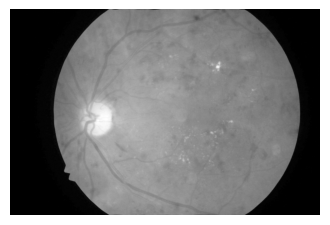

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001026.png"

img = Image.open(img_path).convert("L")

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

Found image at index: 0
Source path: /content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001026.png


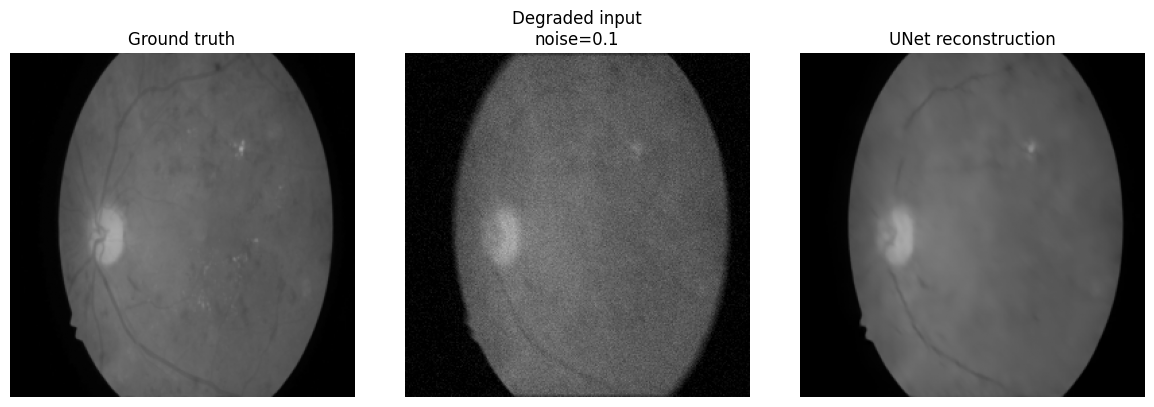

In [22]:
target_path = "/content/drive/MyDrive/Computational Imaging/Dataset/retinal_data/images/retinal_001026.png"
noise_level =  0.1
split = "test"

pt_path = PROCESSED_DATASET_DIR / split / noise_file_name(noise_level)
dataset = RetinaPTDataset(pt_path)

matches = [
    (idx, path)
    for idx, path in enumerate(dataset.source_paths)
    if path == target_path
]

if len(matches) == 0:
    print("Image not found in this split/noise level.")
    print("Try split='train' or split='validation'.")
else:
    sample_index = matches[0][0]
    print("Found image at index:", sample_index)
    print("Source path:", matches[0][1])

    tag = noise_tag(noise_level)

    model = UNet(
        in_channels=1,
        out_channels=1,
        features=(32, 64, 128, 256),
        final_sigmoid=False,
    ).to(device)

    checkpoint_path = WORK_DIR / f"unet_no_sigmoid_{tag}.pt"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    y, x = dataset[sample_index]

    y = y.unsqueeze(0).to(device)  # degraded
    x = x.unsqueeze(0).to(device)  # ground truth

    with torch.no_grad():
        x_hat = model(y).clamp(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(x.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Ground truth")
    axes[0].axis("off")

    axes[1].imshow(y.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Degraded input\nnoise={noise_level}")
    axes[1].axis("off")

    axes[2].imshow(x_hat.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("UNet reconstruction")
    axes[2].axis("off")

    #plt.suptitle(f"{target_path}\nindex={sample_index}, split={split}", fontsize=9)
    plt.tight_layout()
    plt.show()